<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Load modules

In [ ]:
from siuba import *
from plotnine import *
from plotnine import *
import numpy as np, pandas as pd
from itables import to_html_datatable
from IPython.display import HTML, display

In [ ]:
from plant_hydraulics.run_sureau import run_sureau
from plant_hydraulics.sureau_climate import *  
from plant_hydraulics.utils import potential_PAR
from plant_hydraulics.parameter_classes import (
    SurEauVegetationParams,
    SurEauSoilParams,
    SurEauModelOptions,
)

from plant_hydraulics.utils import (
    load_example_data,
)

# Object initialization

In [ ]:
# Model options
opts = SurEauModelOptions(
    
    # Richmond
    latitude=-33.5996,
    
    # Meters above sea level
    elevation = 24,
    
    # net radiation model: "Linacre" (only option currently)
    Rn_formulation="Linacre",
    
    # PET model: "PT" (Priestley-Taylor) or "PM" (Penman-Monteith)
    ETP_formulation="PT",
    
    # True → forces a fixed doy=116 (sunny day template)
    constant_climate = False,
    # which hours to output (0–23 → full day)
    time_steps=np.arange(24),
    
    # Print progress to console
    print_progress=True,
    
    year_start=2016,
    year_end=2016
)

In [ ]:
# Vegetation parameters
veg_params = SurEauVegetationParams()

# Leaf area index (m²/m²). Higher = more transpiration.
veg_params.LAI_max = 6
  
veg_params.foliage = "Evergreen"  

veg_params.transpiration_model = "Medlyn"

veg_params.g_crown0 = 1e6 


# Params from Drake 
veg_params.vcmax25 = 34
veg_params.vcmaxha = 51780
veg_params.vcmaxhd = 2e5
veg_params.vcmaxse = 640

veg_params.jmax25 = 60
veg_params.jmaxha = 21640
veg_params.jmaxhd = 2e5
veg_params.jmaxse = 633

veg_params.g1_medlyn = 2.9
veg_params.g0_medlyn = 0.00000001

# ψ at 50% loss of leaf conductance (MPa) 
veg_params.P50_VC_leaf = -3.89

# ψ at 50% loss of stem conductance (MPa)   
veg_params.P50_VC_stem = -3.89

# Steepness of vulnerability sigmoid (%/MPa)   
veg_params.slope_VC_leaf = 50   

# ψ at 12% stomatal closure (MPa)
veg_params.P12_gs = -2.18

# ψ at 88% stomatal closure (MPa)       
veg_params.P88_gs = -4       

# Whole-plant conductance (mmol/m²/s/MPa)
veg_params.k_plant_init = 100  

# At 20°C (mmol/m²/s)
veg_params.gmin20 = 4.0

# Temperature where cuticle melts (°C)         
veg_params.TPhase_gmin = 38


!!! Calculate DEhydration Q10
veg_params.Q10_1_gmin = 1
# Q10 above TPhase    
veg_params.Q10_2_gmin = 3
veg_params.gmin20 = 3

In [ ]:
soil_params = SurEauSoilParams()

## Climate

SurEau takes daily climatic data and then creates a hourly dataset 

In [ ]:
climate_df = load_example_data("sureau_medlyn_daily_climate.csv", sep=",")
#climate_df["DATE"] = pd.to_datetime(climate_df["DATE"], format="%d/%m/%Y").dt.strftime("%Y-%m-%d")
html_str = to_html_datatable(climate_df)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


### Explore climatic data

In [ ]:
hourly_data_from_daily = []
for each_day in range(len(climate_df)):
    
    # Get date 
    date_str = str(climate_df.iloc[each_day]["DATE"])              
   
    # Calculate climate for that day
    clim = new_climate_day(climate_df, date_str)
    
    # Compute PET for that day
    clim = compute_Rn_and_ETP(clim, veg_params, opts)
    
    # Create hourly climate from daily conditions     
    ch   = new_climate_hourly(clim, opts, veg_params)    
    
    #Show data in ch
    #print("ch.__dict__ keys:", list(vars(ch).keys()))
    
    # Put everything into frame that works for Sureau
    hourly_data_from_daily.append(pd.DataFrame({
        "Doy":    int(climate_df.iloc[each_day]["DOY"]),
        "hour":   np.asarray(ch.time, float),
        "RG":     np.asarray(ch.RG, float), 
        "RH":     np.asarray(ch.RH_air_mean, float),           
        "PAR_d":  np.asarray(ch.PAR, float),
        "Tair_d": np.asarray(ch.T_air_mean, float),
        "VPD_d":  np.asarray(ch.VPD, float),
    }))
hourly_data_from_daily = pd.concat(hourly_data_from_daily, ignore_index=True)

## Run the model

In [ ]:
results = run_sureau(
    climate_df=climate_df,
    veg_params=veg_params,
    soil_params=soil_params,
    opts=opts,
    
    # Set True to keep deepest layer at field capacity
    deep_water=False,  
)

Year 2016 Day 305
Year 2016 Day 306
Year 2016 Day 307
Year 2016 Day 308
Year 2016 complete. 


In [ ]:
results = results  >> filter(_.PAR > 0) >> mutate(e_total = _["E_lim"] + _["E_min"]) >> \
    mutate(gres = _["gmin"] + _["gmin_S"])

In [ ]:
html_str = to_html_datatable(results)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


##  Plot results 

In [ ]:
raw_plc = load_example_data("drake_plc_data.csv", sep=",")

In [ ]:
raw_chamber_data = load_example_data("heatwave_raw_data_drake.csv", sep=",")

# Filter data as Drake did
raw_chamber_data = raw_chamber_data >> filter(_.PAR >= 500) >> filter(_.T_treatment == 'ambient')
raw_chamber_data

,DateTime_hr,chamber,T_treatment,HWtrt,combotrt,PAR,PPFD_Avg,Tair_al,TargTempC_Avg,VPD,Photo,Trans,FluxCO2,FluxH2O,LeafArea,Tdiff,leaftoairVPD,gs,Atogs
42,2016-10-29 08:30:00,C09,ambient,HW,ambient_HW,805.4,259.073333,18.411248,18.946667,0.261311,4.653162,0.317972,0.079854,0.005457,17.161261,0.535419,0.333722,0.095281,0.048836
45,2016-10-29 09:00:00,C03,ambient,HW,ambient_HW,1243.8,1398.156667,20.985444,24.001667,0.436916,9.816100,0.758170,0.121192,0.009361,12.346251,3.016223,0.938592,0.080777,0.121520
47,2016-10-29 09:00:00,C07,ambient,HW,ambient_HW,1453.1,1305.076667,20.042771,23.336000,0.363751,8.640184,0.756307,0.126152,0.011043,14.600664,3.293229,0.888600,0.085112,0.101515
48,2016-10-29 09:00:00,C09,ambient,HW,ambient_HW,1556.9,1322.333333,20.100288,22.714000,0.341839,10.455595,0.625009,0.179431,0.010726,17.161261,2.613712,0.751975,0.083116,0.125796
51,2016-10-29 09:30:00,C03,ambient,HW,ambient_HW,1630.4,1597.200000,21.338174,24.484667,0.494652,11.834850,0.727829,0.146116,0.008986,12.346251,3.146493,1.029771,0.070679,0.167446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,2016-11-11 15:00:00,C07,ambient,HW,ambient_HW,1138.9,342.773333,27.244663,28.716333,1.528418,6.530467,1.777868,0.095349,0.025958,14.600664,1.471671,1.853797,0.095904,0.068094
2296,2016-11-11 15:00:00,C09,ambient,HW,ambient_HW,1099.0,1077.433333,26.930350,29.116000,1.432955,6.692262,1.775116,0.114848,0.030463,17.161261,2.185650,1.917356,0.092581,0.072285
2299,2016-11-11 15:30:00,C03,ambient,HW,ambient_HW,989.4,252.983333,26.396116,26.331333,1.217014,2.138628,0.431374,0.026404,0.005326,12.346251,-0.064782,1.203831,0.035833,0.059683
2301,2016-11-11 15:30:00,C07,ambient,HW,ambient_HW,946.8,375.263333,26.470588,27.694000,1.427771,6.061805,1.729572,0.088506,0.025253,14.600664,1.223412,1.686123,0.102577,0.059095


In [ ]:
model_predictions = load_example_data("photosyneb_predictions_heatwave_data_drake.csv", sep=",")
model_predictions = model_predictions >> filter(_.PPFD >= 500 )

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 7 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 6 rows containing missing values.


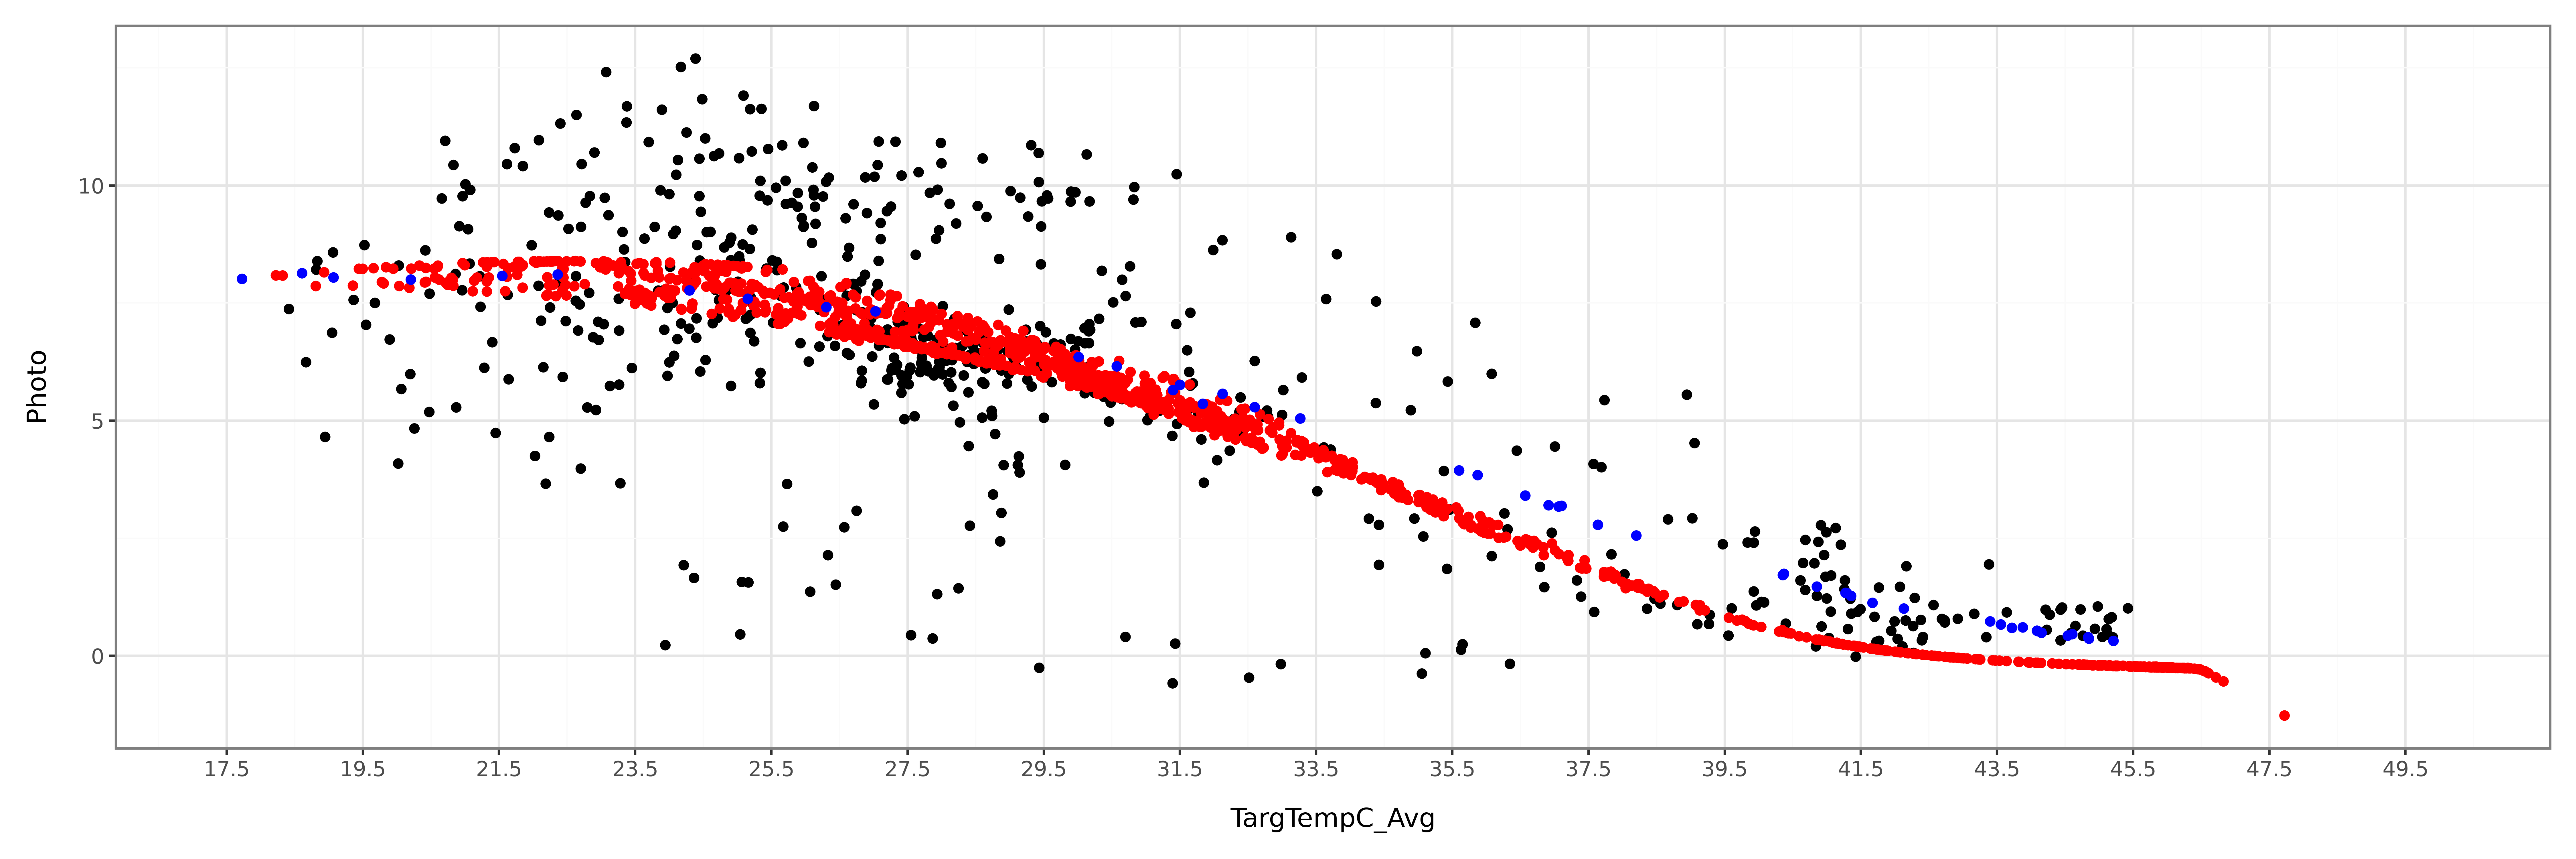

In [ ]:
(ggplot() 
 + geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'Photo')) 
 + geom_point(model_predictions, aes(x="Tleaf", y = "ALEAF"),  color='red') 
 + geom_point(results, aes(x="leaf_temperature", y = "An"),  color='blue') 
 + theme_bw()
 + theme(figure_size=(15, 5), dpi=300)
    + scale_x_continuous(
        breaks=np.arange(17.5, 50, 2), 
        limits=[17.5, 50])
    )

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 7 rows containing non-finite values.


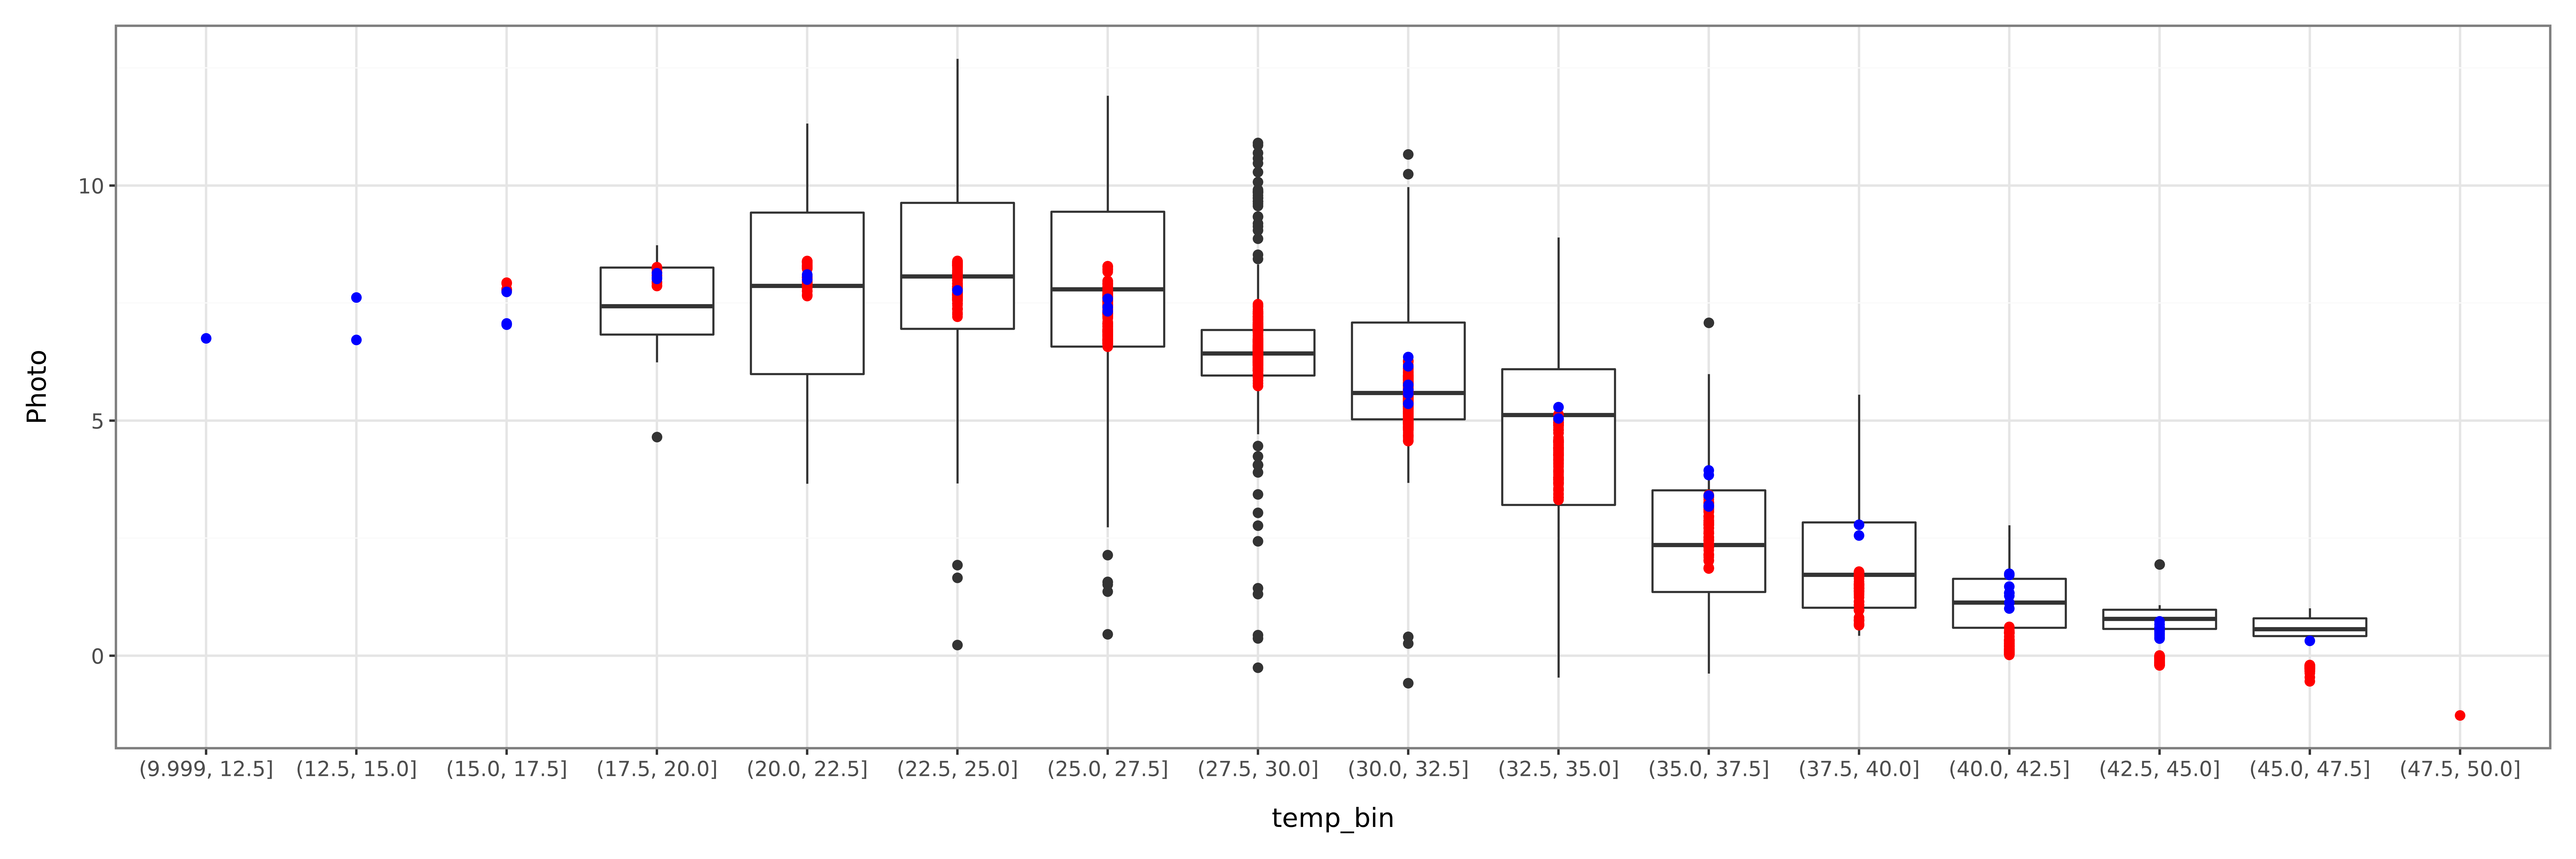

In [ ]:
step = 2.5
lo = np.floor(10 / step) * step
hi = np.ceil (55 / step) * step
breaks = np.arange(lo, hi + step, step)

raw_chamber_data['temp_bin'] = pd.cut(
    raw_chamber_data['TargTempC_Avg'], bins=breaks, include_lowest=True
)

model_predictions['temp_bin'] = pd.cut(
    model_predictions['Tleaf'], bins=breaks, include_lowest=True
)

results['temp_bin'] = pd.cut(
    results['leaf_temperature'], bins=breaks, include_lowest=True
)


(ggplot()
 + geom_boxplot(raw_chamber_data, aes(x='temp_bin', y='Photo')) 
 + geom_point(model_predictions, aes(x='temp_bin', y = "ALEAF"),  color='red') 
 + geom_point(results, aes(x='temp_bin', y = "An"),  color='blue') 
 + theme_bw()
 + theme(figure_size=(15, 5), dpi=300)
 
   )

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'y' is already present.
Adding another scale for 'y',
which will replace the existing scale.

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 20 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 6 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/

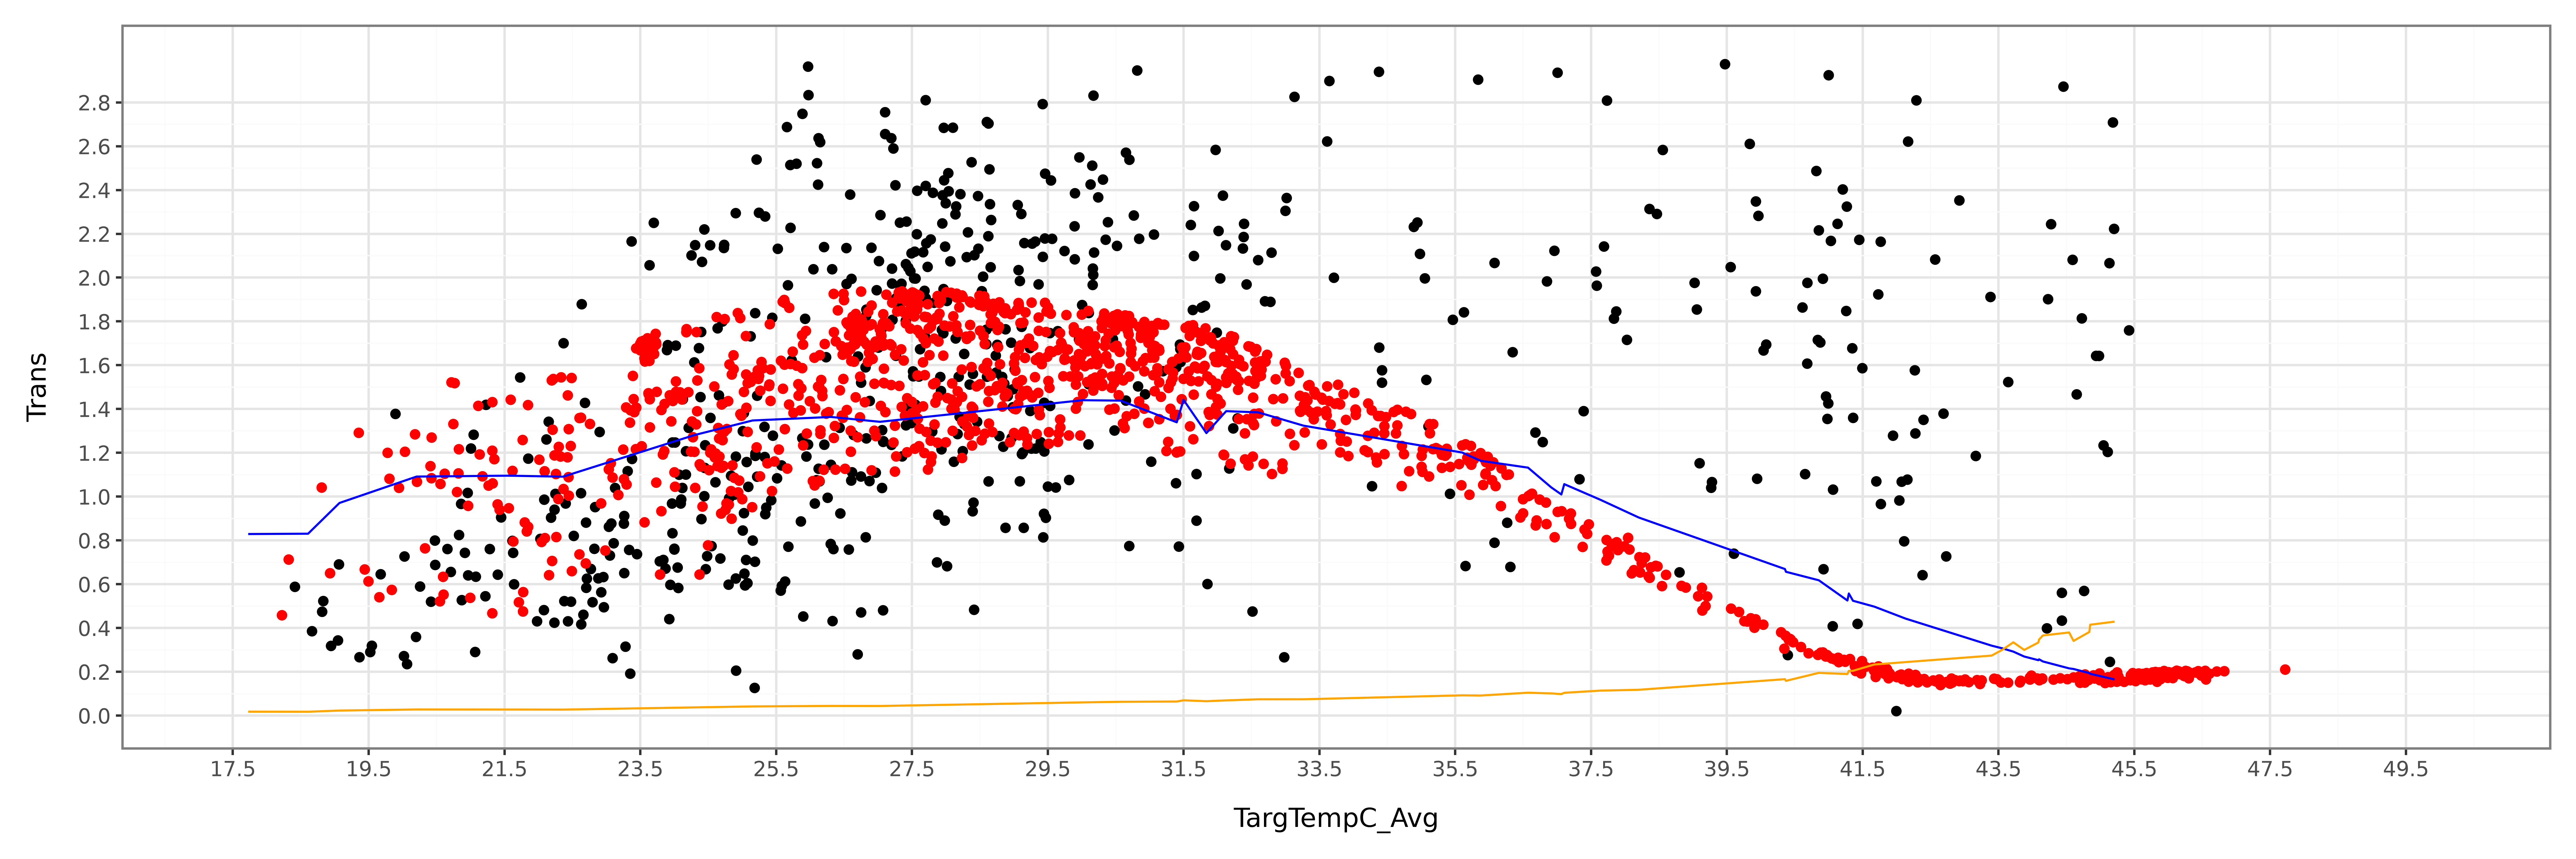

In [ ]:
(ggplot() 
    + geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'Trans')) 
    + geom_point(model_predictions, aes(x="Tleaf", y = "ELEAF"),  color='red')  
    + geom_line(results, aes(x="leaf_temperature", y = "E_lim"),  color='blue') 
    + geom_line(results, aes(x="leaf_temperature", y = "E_min"),  color='orange') 
    + ylim(0,3.1)
    + theme_bw()
    + theme(figure_size=(15, 5), dpi=300)
    + scale_y_continuous(
        breaks=np.arange(0, 3, 0.2), 
        limits=[0, 3])
    + scale_x_continuous(
        breaks=np.arange(17.5, 50, 2), 
        limits=[17.5, 50])
    )

In [ ]:
step = 2.5
lo = np.floor(10 / step) * step
hi = np.ceil (55 / step) * step
breaks = np.arange(lo, hi + step, step)

raw_chamber_data['temp_bin'] = pd.cut(
    raw_chamber_data['TargTempC_Avg'], bins=breaks, include_lowest=True
)

model_predictions['temp_bin'] = pd.cut(
    model_predictions['Tleaf'], bins=breaks, include_lowest=True
)

results['temp_bin'] = pd.cut(
    results['leaf_temperature'], bins=breaks, include_lowest=True
)

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 20 rows containing non-finite values.


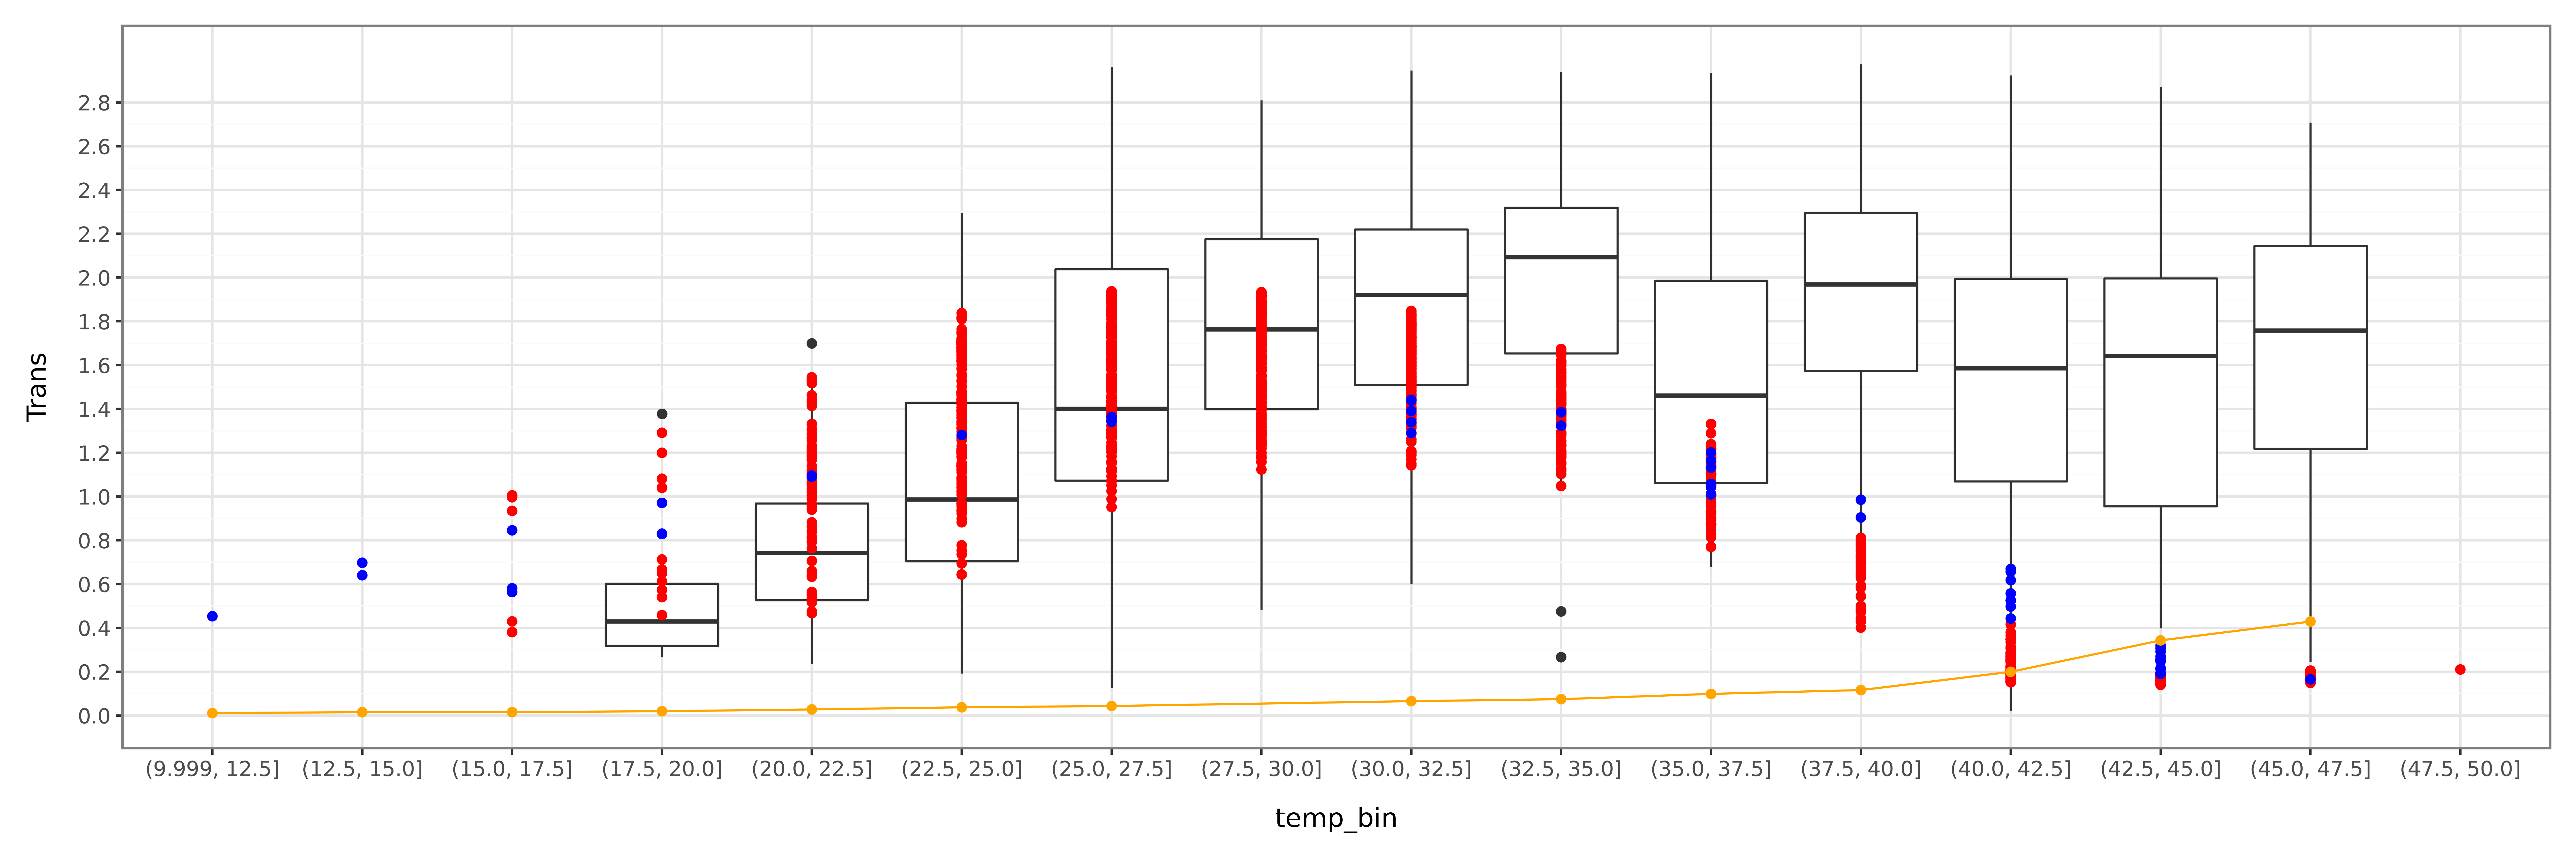

In [ ]:
emin_bin = (results.groupby('temp_bin', observed=True)['E_min']
                   .mean().reset_index())          # one E_min per bin

(ggplot()
 + geom_boxplot(raw_chamber_data, aes(x='temp_bin', y='Trans'))
 + geom_point(model_predictions, aes(x='temp_bin', y='ELEAF'), color='red')
 + geom_point(results,           aes(x='temp_bin', y='E_lim'),  color='blue')
 + geom_line (emin_bin, aes(x='temp_bin', y='E_min', group=1), color='orange')
 + geom_point(emin_bin, aes(x='temp_bin', y='E_min'), color='orange') 
 + theme_bw() 
 + scale_y_continuous(
        breaks=np.arange(0, 3, 0.2), 
        limits=[0, 3])
 + theme(figure_size=(15, 5), dpi=300)
)

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 20 rows containing non-finite values.


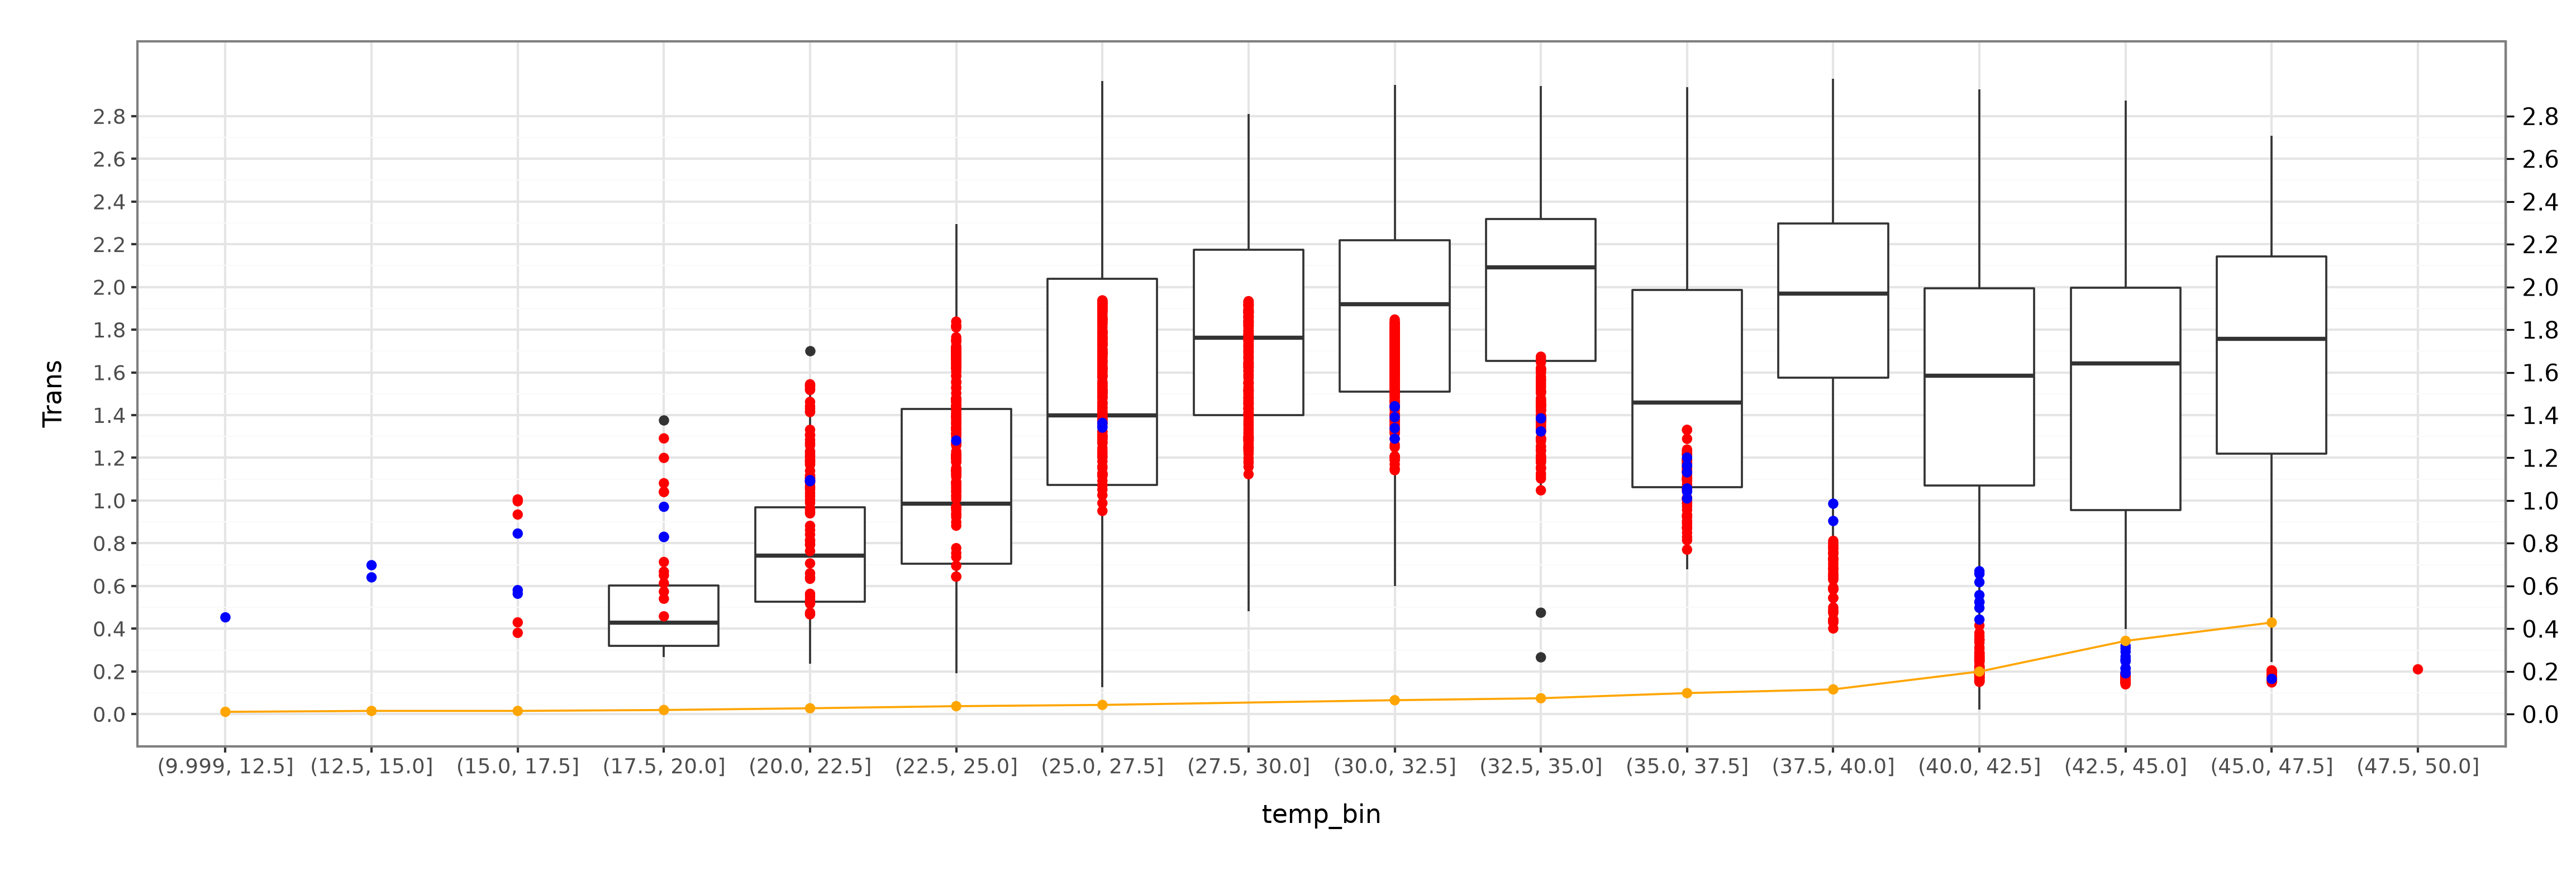

In [ ]:
p = (ggplot()
 + geom_boxplot(raw_chamber_data, aes(x='temp_bin', y='Trans'))
 + geom_point(model_predictions, aes(x='temp_bin', y='ELEAF'), color='red')
 + geom_point(results,           aes(x='temp_bin', y='E_lim'),  color='blue')
 + geom_line (emin_bin, aes(x='temp_bin', y='E_min', group=1), color='orange')
 + geom_point(emin_bin, aes(x='temp_bin', y='E_min'), color='orange') 
 + theme_bw() 
 + scale_y_continuous(
        breaks=np.arange(0, 3, 0.2), 
        limits=[0, 3])
 + theme(figure_size=(15, 5), dpi=300)
)



fig = p.draw()
ax = fig.axes[0]
secax = ax.secondary_yaxis("right")   # identity transform = same scale
secax.set_ylabel("")                   # name = NULL
secax.set_yticks(ax.get_yticks())      # force identical breaks (labels = waiver()

fig

/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 6 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 6 rows containing missing values.
/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 15 rows containing missing values.


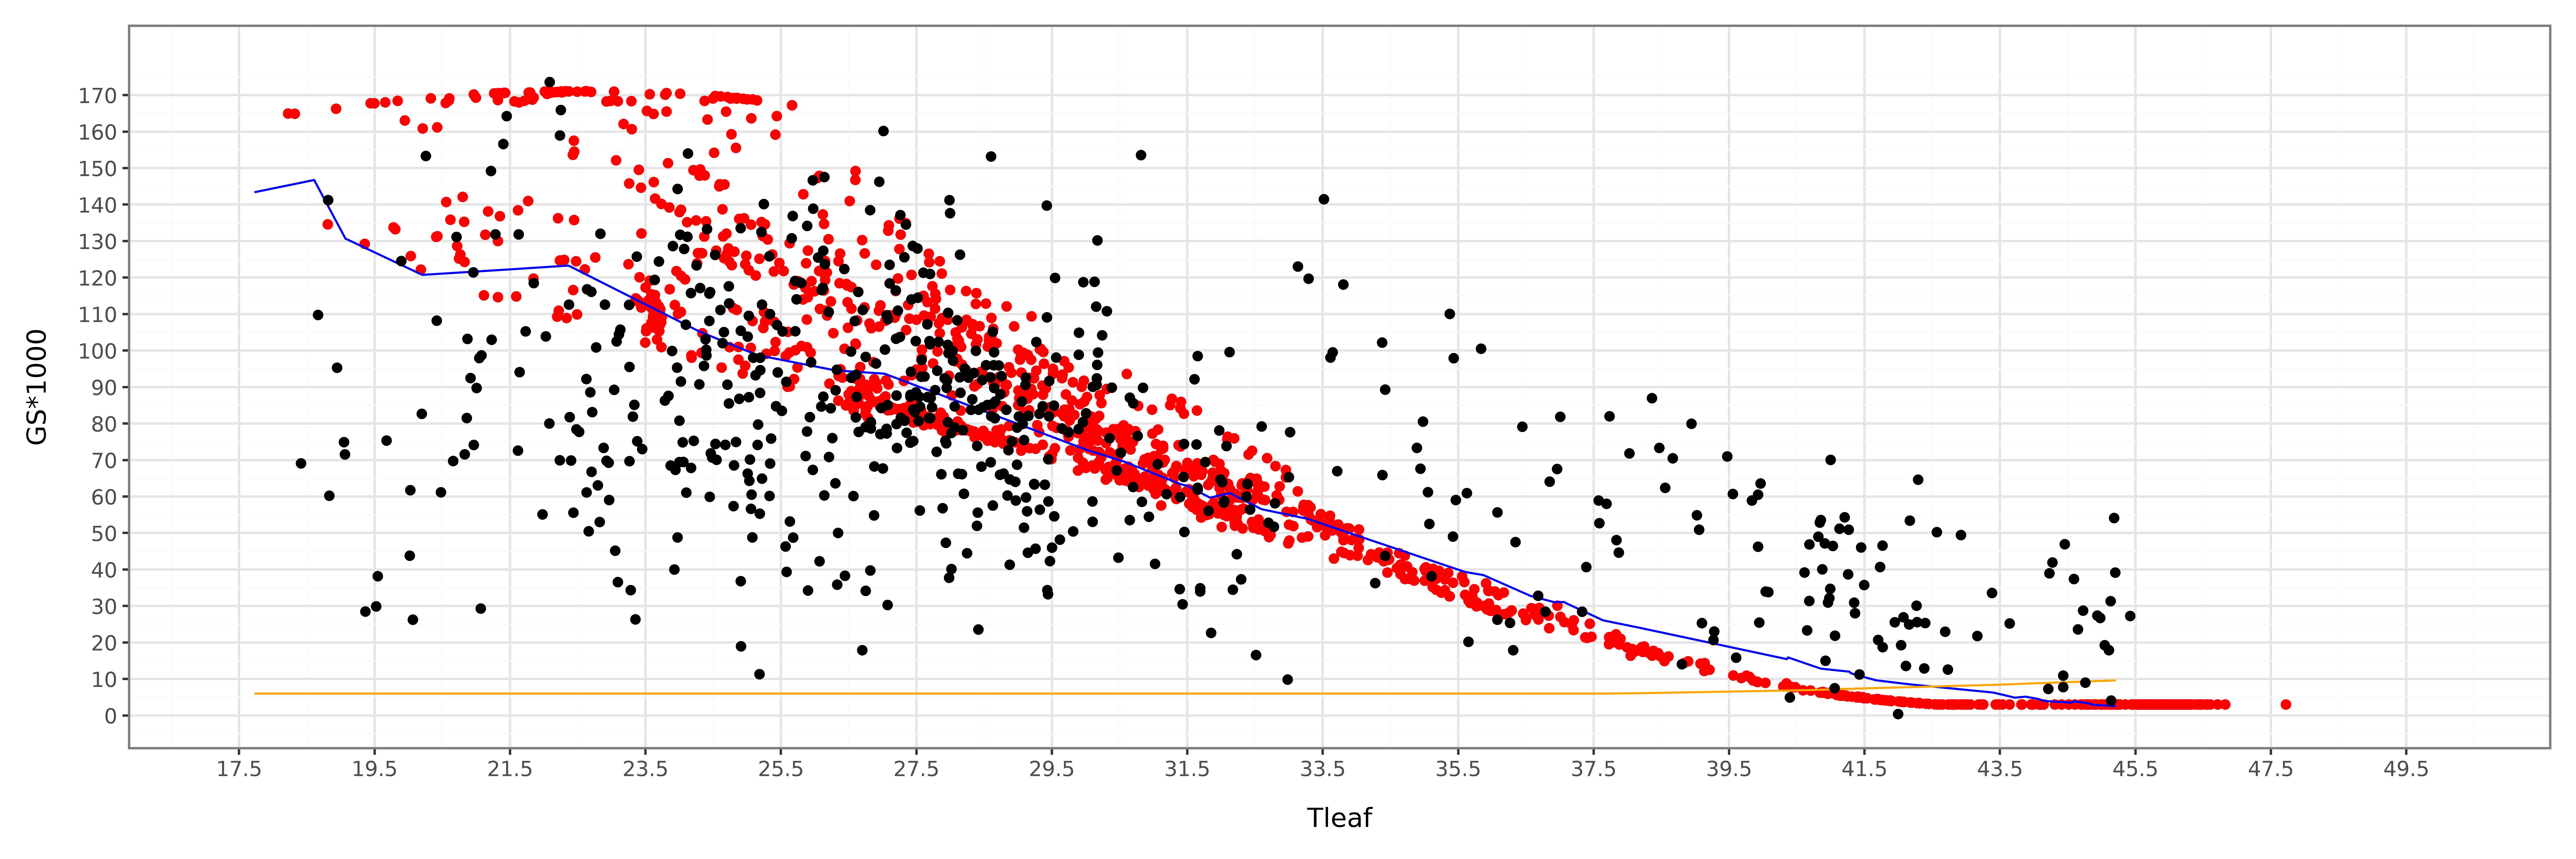

In [ ]:
(ggplot() + 
    geom_point(model_predictions, aes(x="Tleaf", y = "GS*1000"), color='red') 
    + geom_line(results, aes(x="leaf_temperature", y = "gs_lim"), color='blue') 
    + geom_line(results, aes(x="leaf_temperature", y = "gres"),  color='orange') 
    + geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'gs*1000')) 
    + scale_y_continuous(
        breaks=np.arange(0, 180, 10), 
        limits=[0, 180])
    + theme_bw()
    + theme(figure_size=(15, 5), dpi=300)
    + scale_x_continuous(
        breaks=np.arange(17.5, 50, 2), 
        limits=[17.5, 50])
    )

In [ ]:
gres_bin = (results.groupby('temp_bin', observed=True)['gres']
                   .mean().reset_index())          

(ggplot()
 + geom_boxplot(raw_chamber_data, aes(x='temp_bin', y='(gs*1000)'))
 + geom_point(model_predictions, aes(x='temp_bin', y='GS*1000'), color='red')
 + geom_point(results,           aes(x='temp_bin', y='gs_bound'),  color='blue')
 + geom_line (gres_bin, aes(x='temp_bin', y='gres', group=1), color='orange')
 + geom_point(gres_bin, aes(x='temp_bin', y='gres'),          color='orange')
 + theme_bw()
 + scale_y_continuous(
        breaks=np.arange(0, 180, 10), 
        limits=[0, 180]
    )
 + theme(figure_size=(15, 5))
 )

PlotnineError: "Could not evaluate the 'y' mapping: 'log(gs*1000)' (original error: name 'log' is not defined)"

<plotnine.ggplot.ggplot object>

In [ ]:
(raw_plc >> filter(_.HW_treatment == "heatwave") >> 
 select('T_treatment', 'HW_treatment', 'plc') 
 
 )

,T_treatment,HW_treatment,plc
4,ambient,heatwave,7.159086
5,ambient,heatwave,6.325573
6,elevated,heatwave,7.594950
7,elevated,heatwave,3.176804
12,ambient,heatwave,7.540274
13,ambient,heatwave,6.877202
16,ambient,heatwave,2.091609
17,ambient,heatwave,6.171386
18,elevated,heatwave,0.141553
19,elevated,heatwave,0.547783


In [ ]:
(ggplot()
 + geom_point(raw_chamber_data, aes(x = 'T_air', y = 'PLC_leaf'))
 )

raw_chamber_data

,DateTime_hr,chamber,T_treatment,HWtrt,combotrt,PAR,PPFD_Avg,Tair_al,TargTempC_Avg,VPD,Photo,Trans,FluxCO2,FluxH2O,LeafArea,Tdiff,leaftoairVPD,gs,Atogs,temp_bin
42,2016-10-29 08:30:00,C09,ambient,HW,ambient_HW,805.4,259.073333,18.411248,18.946667,0.261311,4.653162,0.317972,0.079854,0.005457,17.161261,0.535419,0.333722,0.095281,0.048836,"(17.5, 20.0]"
45,2016-10-29 09:00:00,C03,ambient,HW,ambient_HW,1243.8,1398.156667,20.985444,24.001667,0.436916,9.816100,0.758170,0.121192,0.009361,12.346251,3.016223,0.938592,0.080777,0.121520,"(22.5, 25.0]"
47,2016-10-29 09:00:00,C07,ambient,HW,ambient_HW,1453.1,1305.076667,20.042771,23.336000,0.363751,8.640184,0.756307,0.126152,0.011043,14.600664,3.293229,0.888600,0.085112,0.101515,"(22.5, 25.0]"
48,2016-10-29 09:00:00,C09,ambient,HW,ambient_HW,1556.9,1322.333333,20.100288,22.714000,0.341839,10.455595,0.625009,0.179431,0.010726,17.161261,2.613712,0.751975,0.083116,0.125796,"(22.5, 25.0]"
51,2016-10-29 09:30:00,C03,ambient,HW,ambient_HW,1630.4,1597.200000,21.338174,24.484667,0.494652,11.834850,0.727829,0.146116,0.008986,12.346251,3.146493,1.029771,0.070679,0.167446,"(22.5, 25.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,2016-11-11 15:00:00,C07,ambient,HW,ambient_HW,1138.9,342.773333,27.244663,28.716333,1.528418,6.530467,1.777868,0.095349,0.025958,14.600664,1.471671,1.853797,0.095904,0.068094,"(27.5, 30.0]"
2296,2016-11-11 15:00:00,C09,ambient,HW,ambient_HW,1099.0,1077.433333,26.930350,29.116000,1.432955,6.692262,1.775116,0.114848,0.030463,17.161261,2.185650,1.917356,0.092581,0.072285,"(27.5, 30.0]"
2299,2016-11-11 15:30:00,C03,ambient,HW,ambient_HW,989.4,252.983333,26.396116,26.331333,1.217014,2.138628,0.431374,0.026404,0.005326,12.346251,-0.064782,1.203831,0.035833,0.059683,"(25.0, 27.5]"
2301,2016-11-11 15:30:00,C07,ambient,HW,ambient_HW,946.8,375.263333,26.470588,27.694000,1.427771,6.061805,1.729572,0.088506,0.025253,14.600664,1.223412,1.686123,0.102577,0.059095,"(27.5, 30.0]"
